# TIME SERIES CLASSIFICATION USING SIMPLE RNN

## IMPORT LIBRARIES

In [3]:
import numpy as np # mathematical operations and array handling
import pandas as pd # Pandas for loading and handling tabular dataset
import matplotlib.pyplot as plt # plotting graphs
import seaborn as sns # better visualization of confusion matrix
from tensorflow.keras.models import Sequential # model allows stacking layers one after another
from tensorflow.keras.layers import (
    Input,
    SimpleRNN,        # recurrent layer for sequential learning
    Dense          # Dense → fully connected classification layers
)
from tensorflow.keras.callbacks import EarlyStopping # prevents overfitting
from sklearn.model_selection import train_test_split # Train-test split for model evaluation
from sklearn.preprocessing import StandardScaler # StandardScaler for feature normalization
from sklearn.metrics import classification_report, confusion_matrix # Evaluation metrics

## LOAD DATASET

- This dataset (module_157_data.csv) is assumed to be a structured
- time-series / sequential feature dataset

In [4]:
df = pd.read_csv("module_157_data.csv")

print("Dataset shape:", df.shape)


Dataset shape: (2000, 11)


In [5]:
X = df.drop("target", axis=1).values
y = df["target"].values

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (2000, 10)
Target shape: (2000,)


## FEATURE SCALING

RNNs are sensitive to scale because they perform repeated multiplication

Standardization formula:
`z = (x - μ) / σ`

 where:
- μ = mean
- σ = standard deviation

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

## RESHAPING FOR RNN

RNN expects 3D input: `(samples, timesteps, features)`

Here we treat each feature as a timestep

WARNING: This assumes features have sequential meaning

In [7]:
X = X.reshape((X.shape[0], X.shape[1], 1))
print("RNN input shape:", X.shape)

RNN input shape: (2000, 10, 1)


## TRAIN TEST SPLIT

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (1600, 10, 1)
Testing shape: (400, 10, 1)


## BUILD RNN MODEL

- **SIMPLE RNN LAYER:** RNN processes data sequentially
  - Hidden state: This allows the network to "remember" previous inputs `h_t = tanh(Wx_t + Uh_{t-1} + b)` where;
    - x_t = input at time step t
    - h_{t-1} = previous memory state
- **Dense:** Output Layer
    - Binary classification output

In [9]:
model = Sequential([

    Input(shape=(X_train.shape[1], 1)),
    SimpleRNN(32),
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

## COMPILE MODEL

**Optimizer:** Adam combines Momentum and Adaptive learning rate
  - Weight update idea: `θ = θ - α * gradient`

**Loss function:** Binary Crossentropy
  - `L = -[y log(p) + (1-y) log(1-p)]`

In [10]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## TRAIN MODEL

- Early stopping prevents overfitting
- Stops training when validation loss stops improving

In [11]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6438 - loss: 0.6182 - val_accuracy: 0.8500 - val_loss: 0.4477
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8617 - loss: 0.3460 - val_accuracy: 0.8750 - val_loss: 0.2837
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8930 - loss: 0.2589 - val_accuracy: 0.9125 - val_loss: 0.2316
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9000 - loss: 0.2327 - val_accuracy: 0.9281 - val_loss: 0.2025
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9281 - loss: 0.1971 - val_accuracy: 0.9312 - val_loss: 0.1818
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9266 - loss: 0.1814 - val_accuracy: 0.9563 - val_loss: 0.1641
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9406 - loss: 0.1652 - val_accuracy: 0.9531 - val_loss: 0.1500
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9438 - loss: 0.1556 - val_accuracy: 0.9500 - val_loss

## EVALUATION
- Precision = TP / (TP + FP)
- Recall    = TP / (TP + FN)
- F1 Score  = 2PR / (P + R)

In [13]:
# ACCURACY AND LOSS
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Loss:", round(test_loss, 4))
print(f"Test Accuracy: {test_acc:4f} -> {test_acc:2%}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9700 - loss: 0.0799  
Test Loss: 0.0799
Test Accuracy: 0.970000 -> 97.000003%


In [14]:
# PREDICTIONS
y_prob = model.predict(X_test)

# Convert probabilities using threshold 0.5 → class labels
y_pred = (y_prob > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [15]:
# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       204
           1       0.97      0.96      0.97       196

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



In [16]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
cm

array([[199,   5],
       [  7, 189]])

## VISUALIZATIONS

### CONFUSION MATRIX

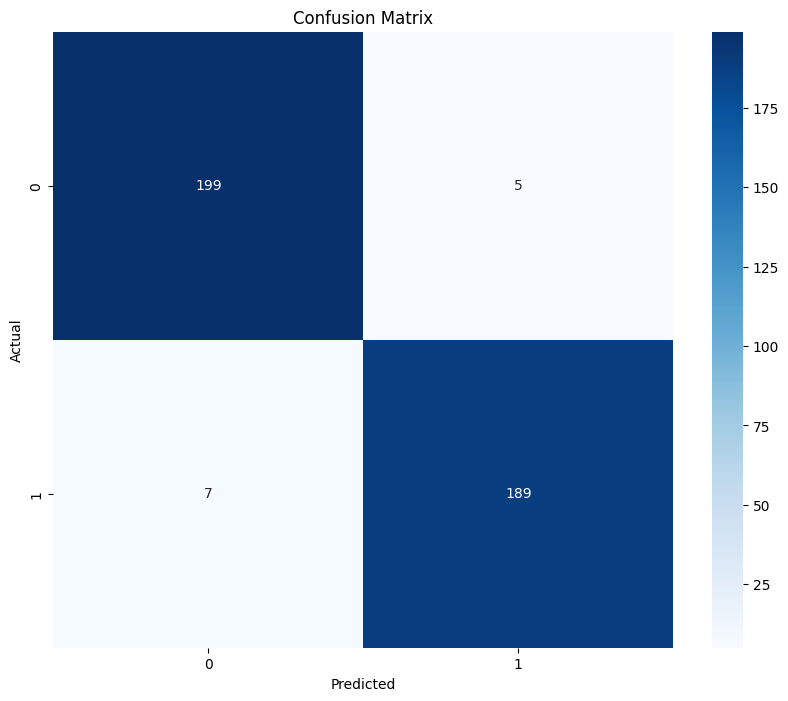

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
    )
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### TRAINING CURVES

#### Loss Curve

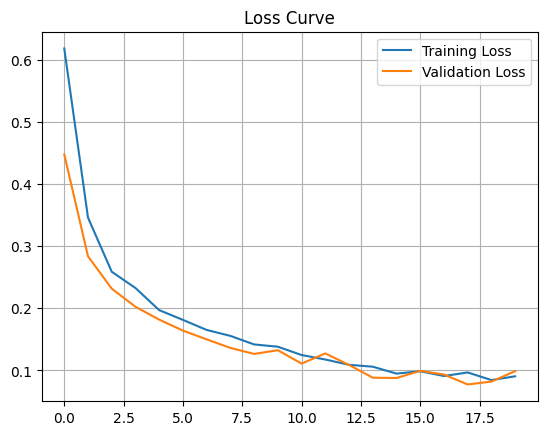

In [18]:
plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid()
plt.show()

#### Accuracy Curve

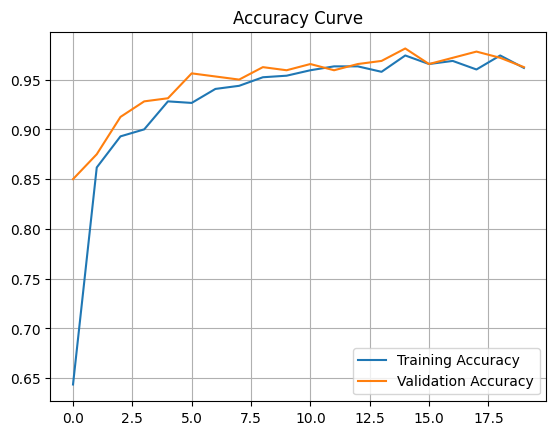

In [19]:
plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid()
plt.show()

## RNN SUMMARY:

1. RNN is designed for sequential / time-series data
2. It uses memory (hidden state) to capture dependencies
3. Each step depends on previous computations

**Hidden state:**
h_t = tanh(Wx_t + Uh_{t-1} + b)

**Output:**
y = sigmoid(W * h_t)

**Loss:**
Binary Crossentropy

Important note:
RNN is only meaningful when data has sequence structure.
If features are artificial sequences, interpretation must be careful.

**Final result:**
Model learns patterns over sequences and performs binary classification.